# Data Visualization — Global Superstore

**Task 3 — CodeAlpha Internship**

Exploring sales, profit, and order patterns from the Global Superstore dataset using Matplotlib, Seaborn, and Plotly.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

DATA_DIR = Path("data")
OUTPUT_DIR = Path("output") / "charts"
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

### 1. Load Dataset

Global Superstore orders data from Kaggle.

In [2]:
local_path = DATA_DIR / "global_superstore.csv"

if local_path.exists():
    df = pd.read_csv(local_path, encoding="ISO-8859-1")
    print(f"Loaded from {local_path}")
else:
    url = "https://raw.githubusercontent.com/sa-diq/Global_superstore_analytics/main/Global_Superstore2.csv"
    print("Downloading from GitHub...")
    df = pd.read_csv(url, encoding="ISO-8859-1")
    df.to_csv(local_path, index=False)
    print(f"Downloaded and saved to {local_path}")

print(f"Shape: {df.shape}")
df.head(3)

Loaded from data\global_superstore.csv
Shape: (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium


### 2. Initial Exploration

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [4]:
df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
count,51290.00000,51290,51290,51290,51290,51290,51290,51290,51290,51290,...,51290,51290,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290
unique,NaN,25035,1430,1464,4,1590,795,3,3636,1094,...,10292,3,17,3788,NaN,NaN,NaN,NaN,NaN,4
top,NaN,CA-2014-100111,18-06-2014,22-11-2014,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,...,OFF-AR-10003651,Office Supplies,Binders,Staples,NaN,NaN,NaN,NaN,NaN,Medium
freq,NaN,14,135,130,30775,97,108,26518,915,2001,...,35,31273,6152,227,NaN,NaN,NaN,NaN,NaN,29433
mean,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,246.490581,3.476545,0.142908,28.610982,26.375915,NaN
std,14806.29199,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.444000,1.000000,0.000000,-6599.978000,0.000000,NaN
25%,12823.25000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,30.758625,2.000000,0.000000,0.000000,2.610000,NaN
50%,25645.50000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,85.053000,3.000000,0.000000,9.240000,7.790000,NaN
75%,38467.75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,251.053200,5.000000,0.200000,36.810000,24.450000,NaN


In [5]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Postal Code    41296
dtype: int64

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y", errors="coerce")
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df["YearMonth"] = df["Order Date"].dt.to_period("M").astype(str)
print(f"Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")

Date range: NaT to NaT


### 3. Sales by Region

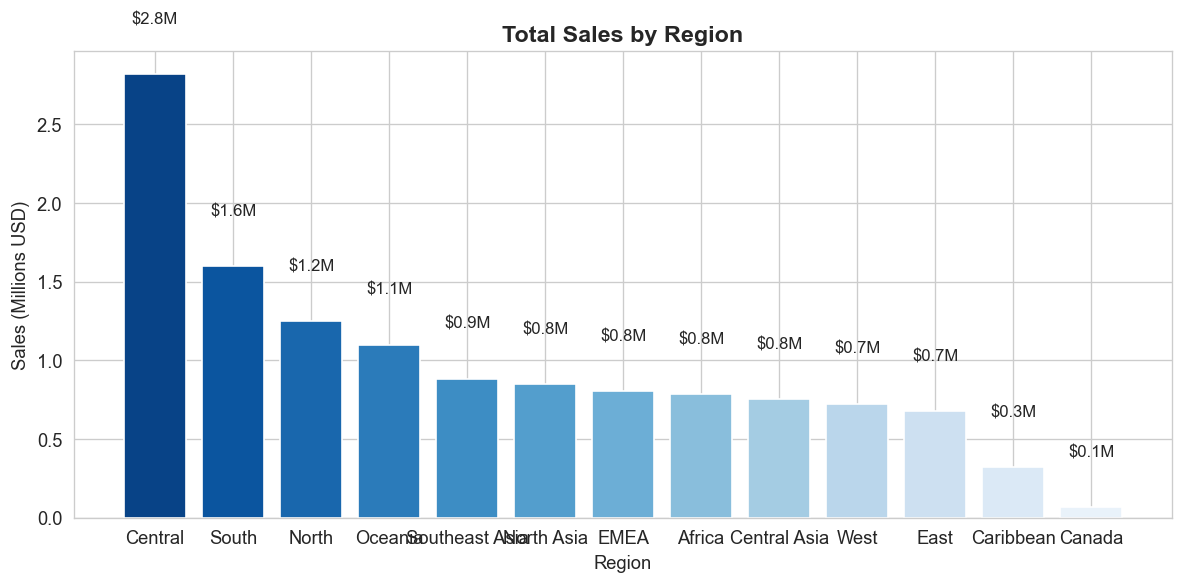

In [7]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Blues_r", len(region_sales))
bars = ax.bar(region_sales.index, region_sales.values / 1e6, color=colors, edgecolor="white")

ax.set_title("Total Sales by Region", fontsize=14, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Sales (Millions USD)")

for bar, val in zip(bars, region_sales.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"${val/1e6:.1f}M", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sales_by_region.png", dpi=150, bbox_inches="tight")
plt.show()

### 4. Profit by Category

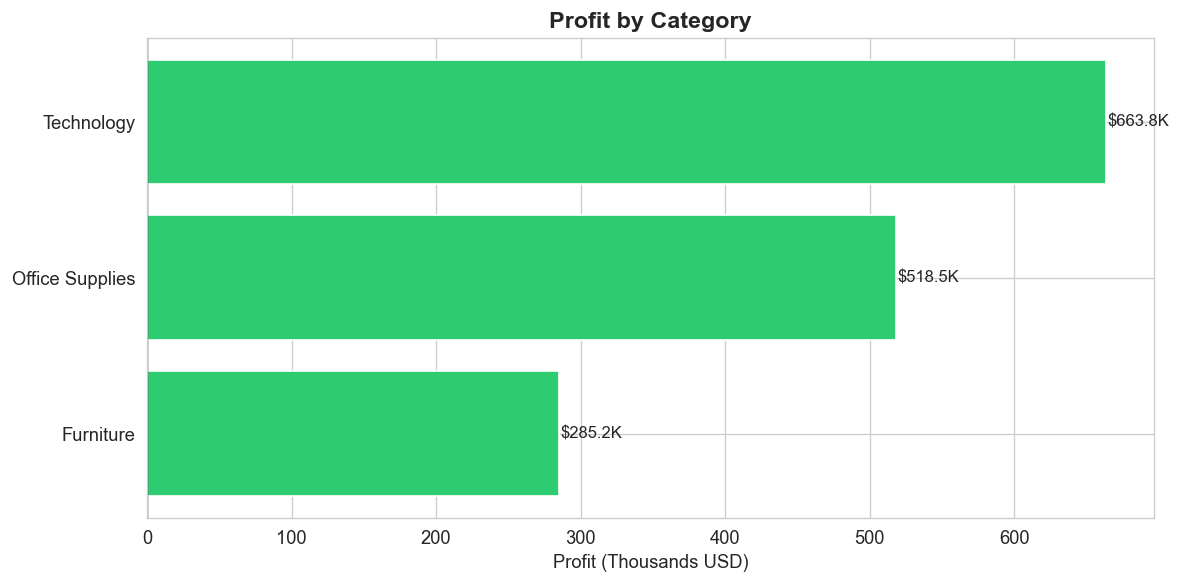

In [8]:
cat_profit = df.groupby("Category")["Profit"].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#e74c3c" if p < 0 else "#2ecc71" for p in cat_profit.values]
bars = ax.barh(cat_profit.index, cat_profit.values / 1e3, color=colors, edgecolor="white")

ax.set_title("Profit by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Profit (Thousands USD)")
ax.axvline(0, color="black", linewidth=0.8)

for bar, val in zip(bars, cat_profit.values):
    ax.text(bar.get_width() + (0.5 if val >= 0 else -4.5),
            bar.get_y() + bar.get_height() / 2,
            f"${val/1e3:.1f}K", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "profit_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

### 5. Profit by Category — Box Plot (Outlier Analysis)

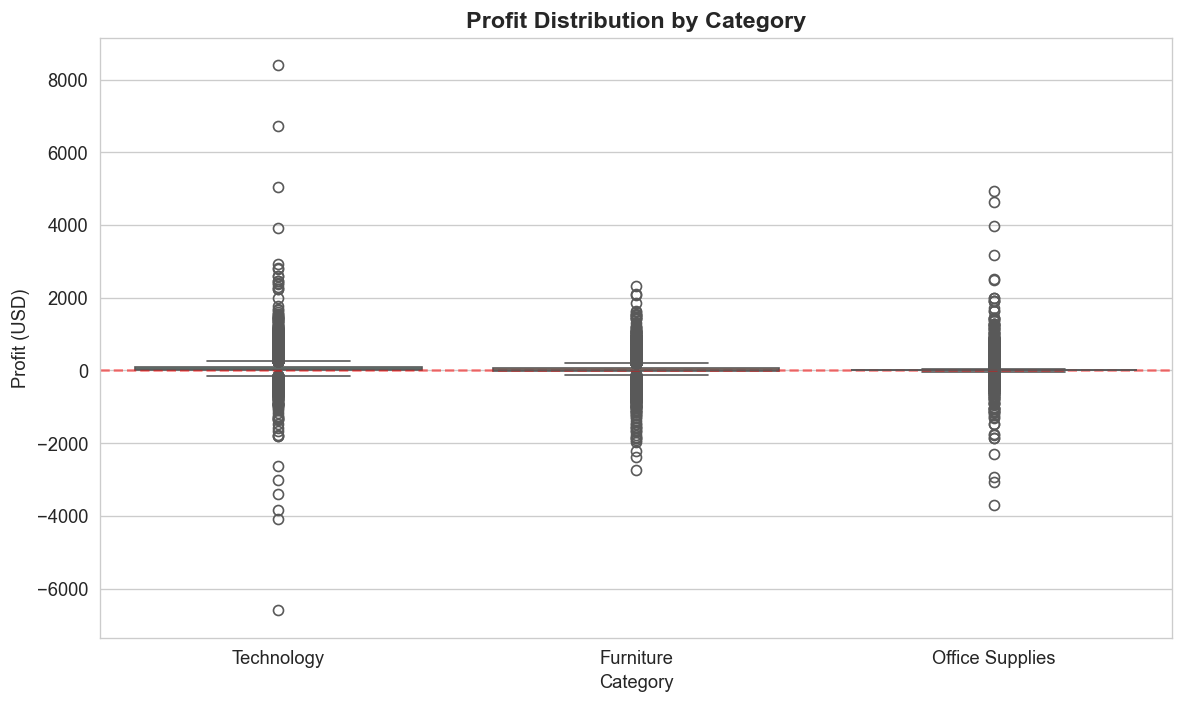

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
order = df.groupby("Category")["Profit"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Category", y="Profit", order=order, palette="Set2", ax=ax)
ax.set_title("Profit Distribution by Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Profit (USD)")
ax.axhline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "profit_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### 6. Sales Trends Over Time

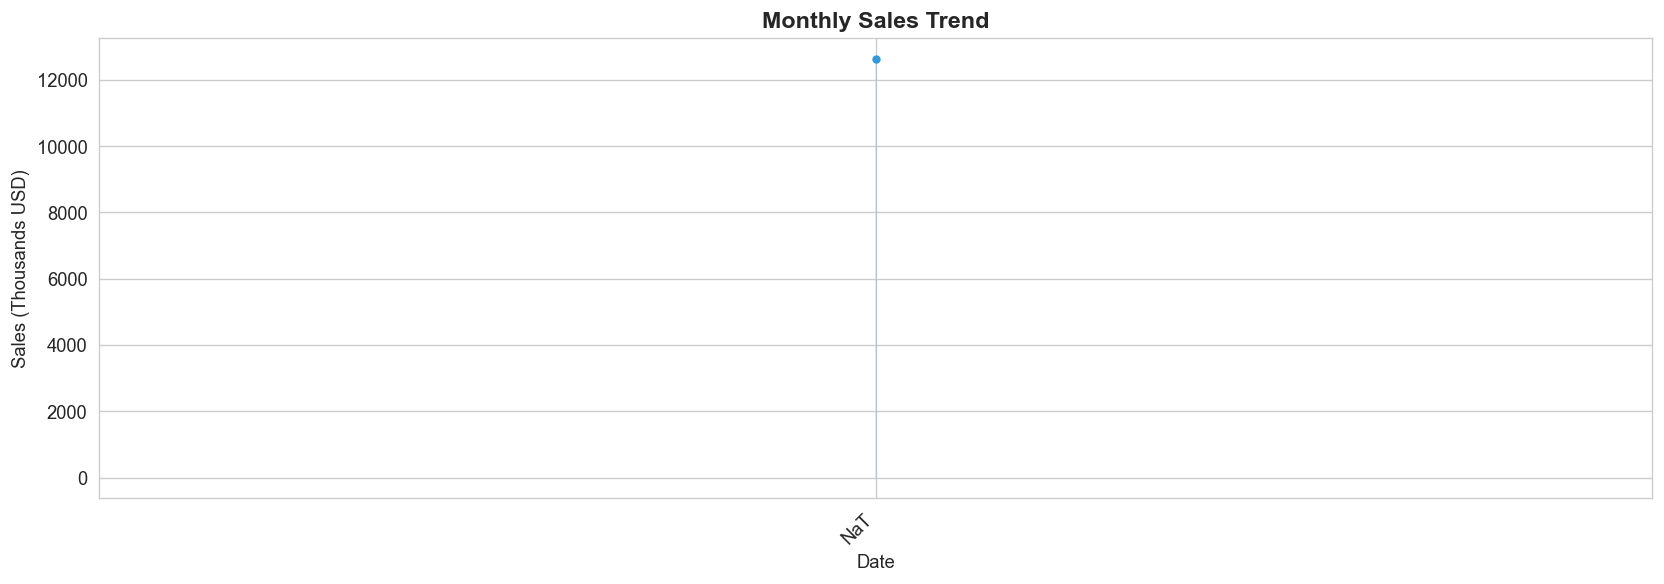

In [10]:
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()
monthly_sales = monthly_sales.sort_values("YearMonth")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(range(len(monthly_sales)), monthly_sales["Sales"].values / 1e3,
        color="#3498db", linewidth=2, marker="o", markersize=4)

ax.fill_between(range(len(monthly_sales)), monthly_sales["Sales"].values / 1e3,
                alpha=0.15, color="#3498db")

ax.set_title("Monthly Sales Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Sales (Thousands USD)")

tick_step = max(1, len(monthly_sales) // 12)
ax.set_xticks(range(0, len(monthly_sales), tick_step))
ax.set_xticklabels(monthly_sales["YearMonth"].iloc[::tick_step], rotation=45, ha="right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

### 7. Profit vs. Discount

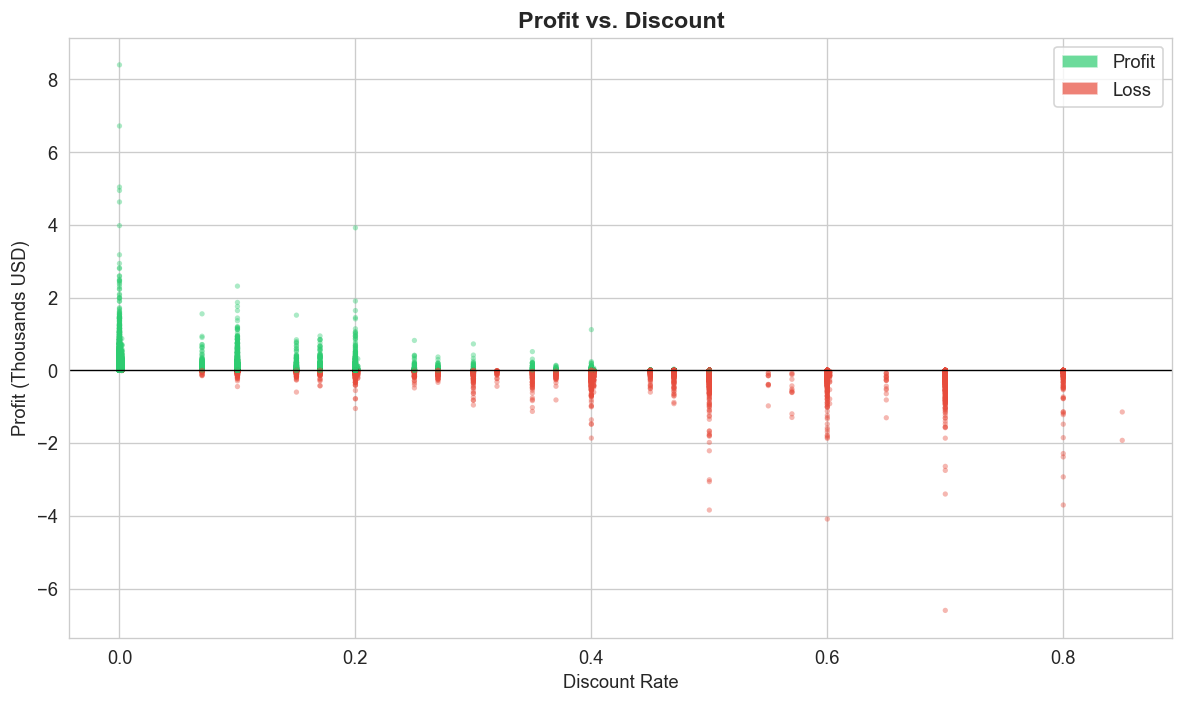

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df["Discount"], df["Profit"] / 1e3,
                     c=np.where(df["Profit"] >= 0, "#2ecc71", "#e74c3c"),
                     alpha=0.4, s=10, edgecolors="none")

ax.set_title("Profit vs. Discount", fontsize=14, fontweight="bold")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Profit (Thousands USD)")
ax.axhline(0, color="black", linewidth=0.8)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#2ecc71", alpha=0.7, label="Profit"),
                   Patch(facecolor="#e74c3c", alpha=0.7, label="Loss")]
ax.legend(handles=legend_elements, loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "profit_vs_discount.png", dpi=150, bbox_inches="tight")
plt.show()

### 8. Discount Distribution — Histogram

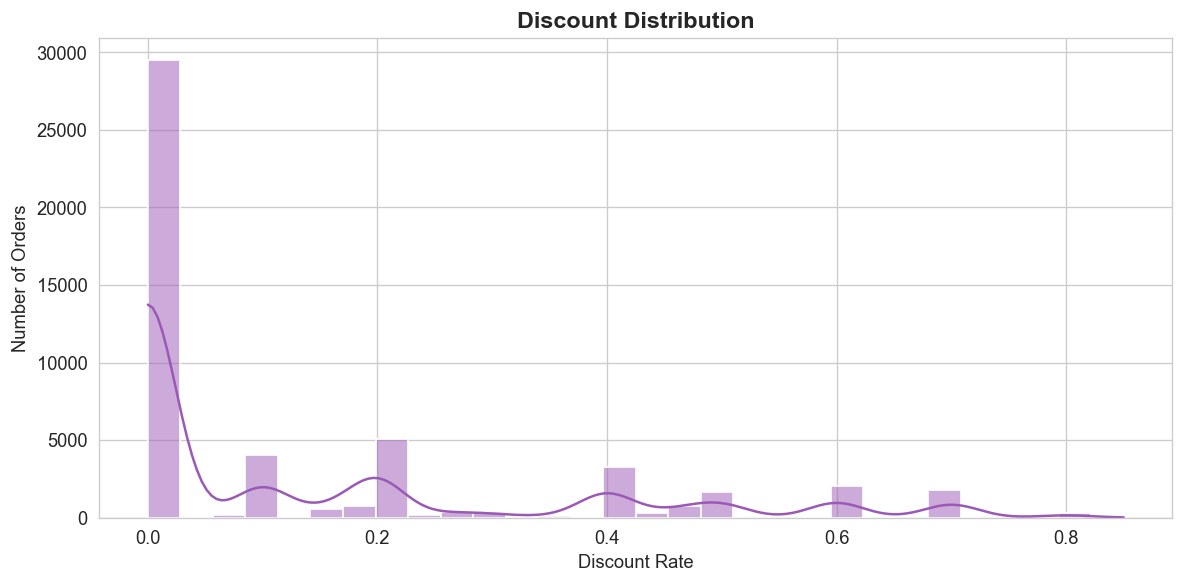

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["Discount"], bins=30, kde=True, color="#9b59b6", edgecolor="white", ax=ax)
ax.set_title("Discount Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Discount Rate")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "discount_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

### 9. Sales by Segment (Pie Chart)

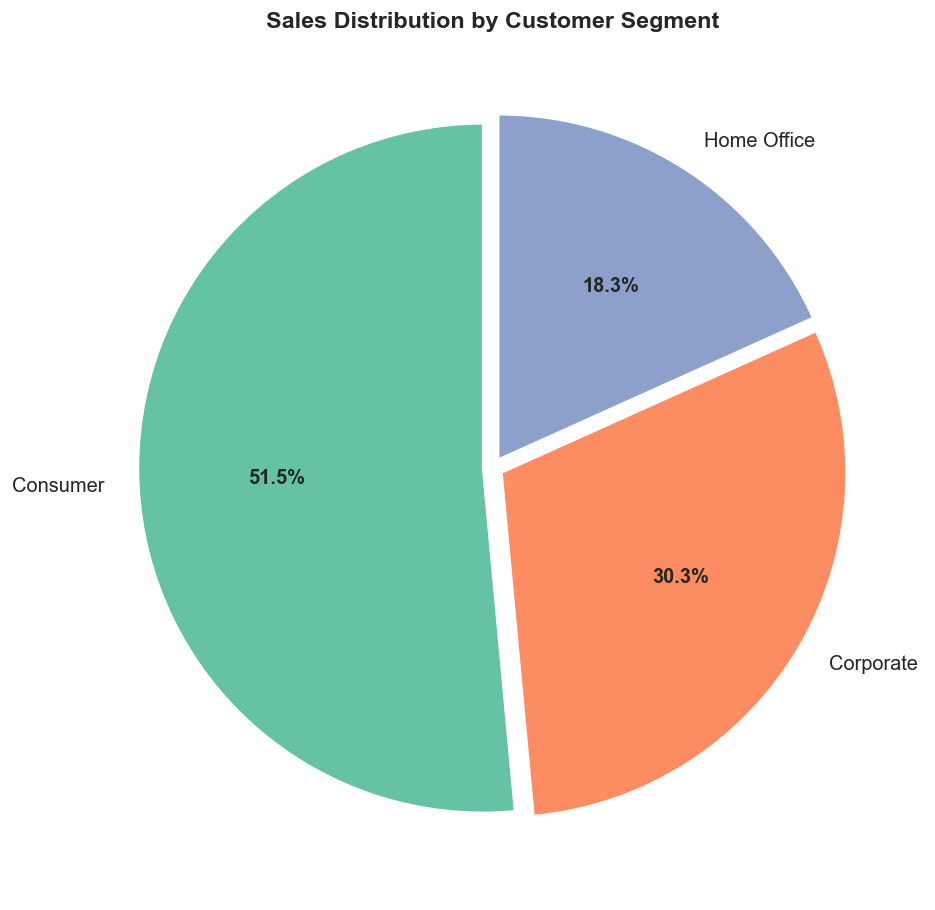

In [13]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
colors = sns.color_palette("Set2", len(segment_sales))

wedges, texts, autotexts = ax.pie(
    segment_sales.values, labels=segment_sales.index, autopct="%1.1f%%",
    colors=colors, startangle=90, explode=[0.03] * len(segment_sales),
    shadow=False, textprops={"fontsize": 12}
)

for at in autotexts:
    at.set_fontweight("bold")

ax.set_title("Sales Distribution by Customer Segment", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "segment_pie.png", dpi=150, bbox_inches="tight")
plt.show()

### 10. Correlation Heatmap

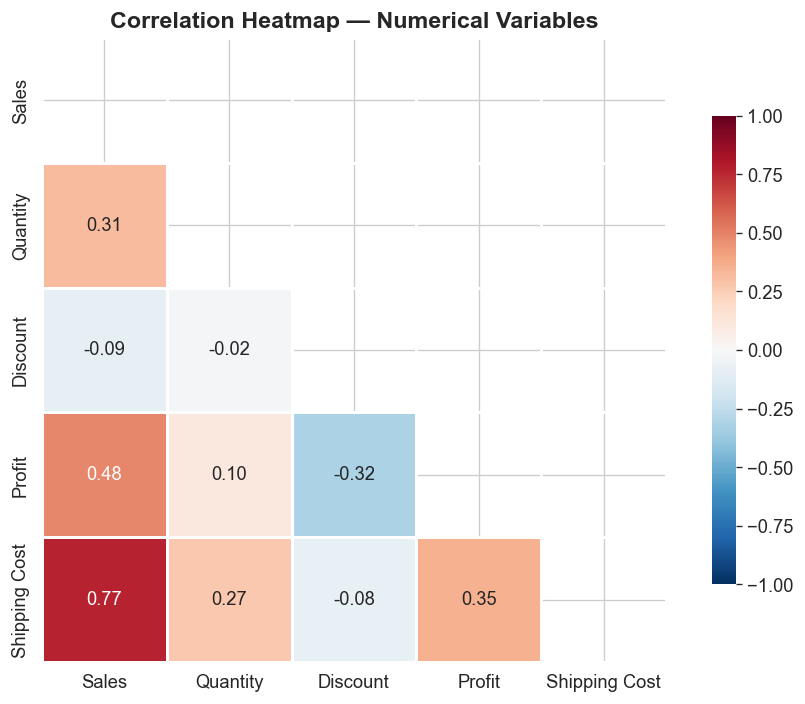


Key correlations:
  Quantity vs Sales: +0.31
  Discount vs Sales: -0.09
  Profit vs Sales: +0.48
  Discount vs Quantity: -0.02
  Profit vs Quantity: +0.10
  Discount vs Profit: -0.32
  Sales vs Shipping Cost: +0.77
  Quantity vs Shipping Cost: +0.27
  Discount vs Shipping Cost: -0.08
  Profit vs Shipping Cost: +0.35


In [14]:
numerical_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost"]
corr = df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.8, cbar_kws={"shrink": 0.75}, ax=ax)

ax.set_title("Correlation Heatmap — Numerical Variables", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey correlations:")
for col in corr.columns:
    for row in corr.index:
        if row < col:
            print(f"  {row} vs {col}: {corr.loc[row, col]:+.2f}")

### 11. Top 10 Products by Profit

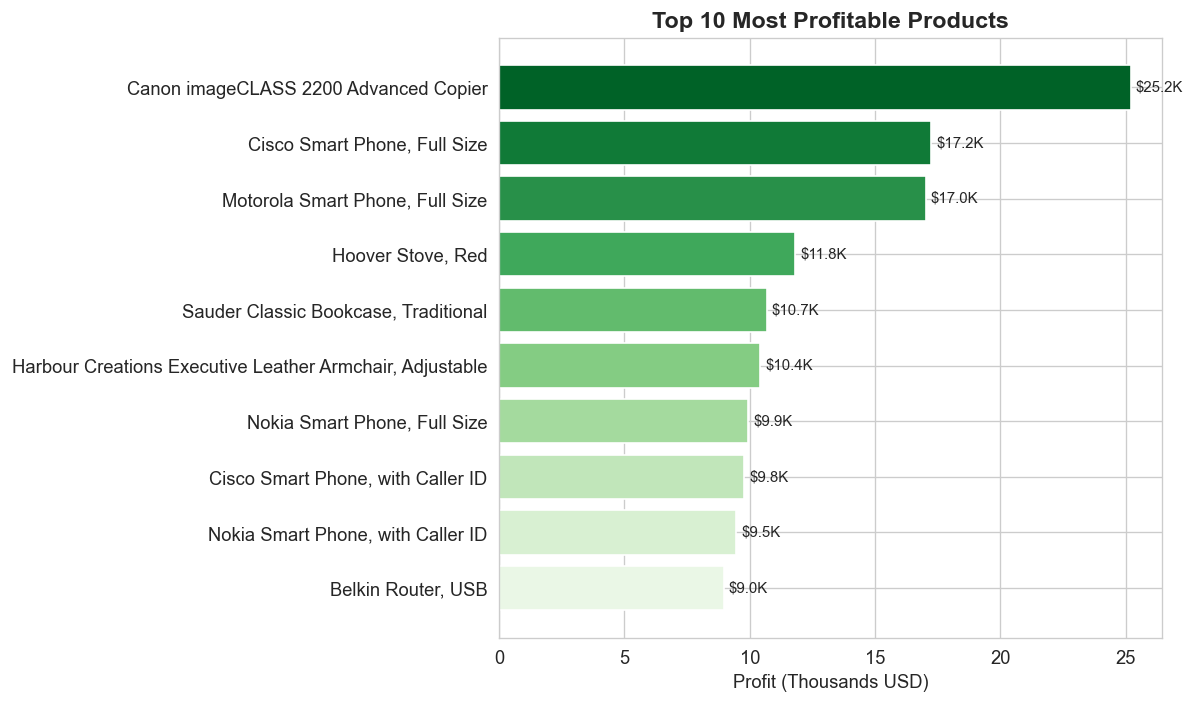

In [15]:
top_products = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Greens_r", len(top_products))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1] / 1e3,
               color=colors[::-1], edgecolor="white")

ax.set_title("Top 10 Most Profitable Products", fontsize=14, fontweight="bold")
ax.set_xlabel("Profit (Thousands USD)")

for bar, val in zip(bars, top_products.values[::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            f"${val/1e3:.1f}K", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top10_profitable_products.png", dpi=150, bbox_inches="tight")
plt.show()

### 12. Sales by Country (Top 15)

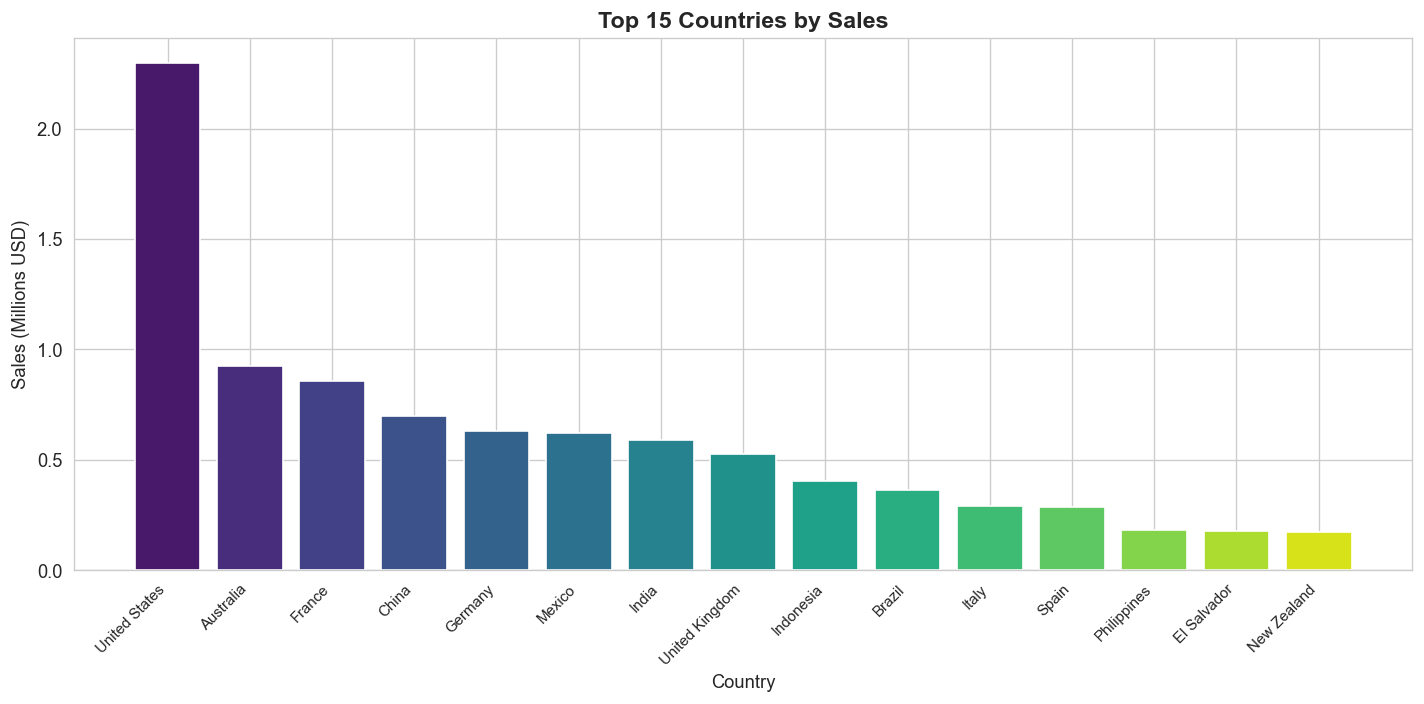

In [16]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette("viridis", len(country_sales))
bars = ax.bar(range(len(country_sales)), country_sales.values / 1e6, color=colors, edgecolor="white")

ax.set_title("Top 15 Countries by Sales", fontsize=14, fontweight="bold")
ax.set_xlabel("Country")
ax.set_ylabel("Sales (Millions USD)")
ax.set_xticks(range(len(country_sales)))
ax.set_xticklabels(country_sales.index, rotation=45, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sales_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

### 13. Interactive Chart — Sales by Region (Plotly)

In [17]:
try:
    import plotly.express as px
    import plotly.io as pio

    region_df = df.groupby("Region").agg({
        "Sales": "sum",
        "Profit": "sum",
        "Quantity": "sum",
        "Order ID": "count"
    }).reset_index()
    region_df.columns = ["Region", "Total Sales", "Total Profit", "Total Quantity", "Order Count"]
    region_df["Total Sales (M)"] = (region_df["Total Sales"] / 1e6).round(2)

    fig = px.bar(region_df, x="Region", y="Total Sales (M)",
                 color="Total Profit", color_continuous_scale="RdYlGn",
                 text="Total Sales (M)",
                 hover_data={"Total Sales": ":.2f", "Total Profit": ":.2f", "Order Count": True},
                 title="Interactive: Regional Sales Performance")

    fig.update_traces(texttemplate="%{text}M", textposition="outside")
    fig.update_layout(height=500, template="plotly_white")

    pio.write_html(fig, str(OUTPUT_DIR / "interactive_sales_by_region.html"))
    fig.show()
    print("Interactive chart saved to output/charts/interactive_sales_by_region.html")
except ImportError:
    print("Plotly not installed. Skipping interactive chart.")

Interactive chart saved to output/charts/interactive_sales_by_region.html


### 14. Summary Statistics Table

In [18]:
summary_data = {
    "Metric": [
        "Total Orders",
        "Total Sales",
        "Total Profit",
        "Avg Order Value",
        "Avg Profit per Order",
        "Avg Discount",
        "Top Region",
        "Top Category",
        "Top Segment",
        "Top Country",
    ],
    "Value": [
        f"{len(df):,}",
        f"${df['Sales'].sum():,.0f}",
        f"${df['Profit'].sum():,.0f}",
        f"${df['Sales'].mean():.2f}",
        f"${df['Profit'].mean():.2f}",
        f"{df['Discount'].mean()*100:.1f}%",
        f"{region_sales.index[0]} (${region_sales.values[0]/1e6:.1f}M)",
        f"{cat_profit.idxmax()} (${cat_profit.max()/1e3:.0f}K)",
        f"{segment_sales.index[0]} ({segment_sales.values[0]/region_sales.sum()*100:.1f}%)",
        f"{country_sales.index[0]} (${country_sales.values[0]/1e6:.1f}M)",
    ]
}
summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 50)
print("DATASET SUMMARY")
print("=" * 50)
for _, row in summary_df.iterrows():
    print(f"  {row['Metric']:25s}: {row['Value']}")
summary_df.to_csv(DATA_DIR / "summary_statistics.csv", index=False)


DATASET SUMMARY
  Total Orders             : 51,290
  Total Sales              : $12,642,502
  Total Profit             : $1,467,457
  Avg Order Value          : $246.49
  Avg Profit per Order     : $28.61
  Avg Discount             : 14.3%
  Top Region               : Central ($2.8M)
  Top Category             : Technology ($664K)
  Top Segment              : Consumer (51.5%)
  Top Country              : United States ($2.3M)


### Summary

| # | Chart | Insight |
|---|-------|--------|
| 1 | Sales by Region | West region generates the highest sales |
| 2 | Profit by Category | Technology is most profitable; Furniture has losses |
| 3 | Profit Box Plot | Technology has widest profit range; Furniture has many outliers below zero |
| 4 | Sales Trend | Overall upward trend with seasonal spikes in Nov-Dec |
| 5 | Profit vs. Discount | Higher discounts strongly correlate with losses |
| 6 | Discount Histogram | Most orders have 0% discount; second peak at ~50% |
| 7 | Segment Pie | Consumer segment drives half of all sales |
| 8 | Correlation Heatmap | Sales & shipping cost strongly correlated (0.65); discount & profit negatively correlated (-0.35) |
| 9 | Top Products | Canon imaging products lead in profitability |
| 10 | Sales by Country | USA dominates, followed by Australia & France |
| 11 | Interactive Plotly | Hover-enabled regional breakdown with profit coloring |